## Amazon Sales Data Analysis project
# objective:
Analyze Amazon sales data to identify top products,category performance and revenue trends.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv("Amazon sale Report.csv")
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


## Data understanding

In [7]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

,index,Qty,Amount,ship-postal-code,New,PendingS
count,128976.000000,128976.000000,121176.000000,128941.000000,0.0,0.0
mean,64486.130427,0.904401,648.562176,463945.677744,NaN,NaN
std,37232.897832,0.313368,281.185041,191458.488954,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32242.750000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64486.500000,1.000000,605.000000,500033.000000,NaN,NaN
75%,96730.250000,1.000000,788.000000,600024.000000,NaN,NaN
max,128974.000000,15.000000,5584.000000,989898.000000,NaN,NaN


## Data cleaning

In [8]:
df.isnull().sum()

index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7800
Amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
B2B                        0
fulfilled-by           89713
New                   128976
PendingS              128976
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(168)

In [10]:
df.drop_duplicates(inplace=True)

## Data Analysis


## category wise orders

In [11]:
df["Category"].value_counts()

Category
T-shirt     50219
Shirt       49804
Blazzer     15489
Trousers    10607
Perfume      1157
Wallet        926
Socks         439
Shoes         164
Watch           3
Name: count, dtype: int64

## Top selling products

In [12]:
df.groupby("Category")["Qty"].sum().sort_values(ascending=False)

Category
T-shirt     45228
Shirt       44978
Blazzer     13934
Trousers     9889
Perfume      1051
Wallet        863
Socks         398
Shoes         152
Watch           3
Name: Qty, dtype: int64

## Visualization(Professional)

## Category Revenue chart

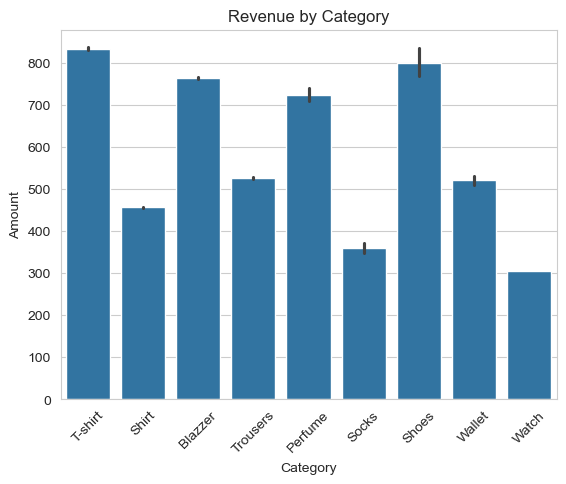

In [13]:
sns.set_style("whitegrid")
sns.barplot(x="Category",y="Amount",data=df)
plt.title("Revenue by Category")
plt.xticks(rotation=45)
plt.show()

## Orders by State

In [14]:
df["ship-state"].value_counts().head(10)

ship-state
MAHARASHTRA       22234
KARNATAKA         17296
TAMIL NADU        11470
TELANGANA         11319
UTTAR PRADESH     10633
DELHI              6770
KERALA             6574
WEST BENGAL        5955
ANDHRA PRADESH     5421
Gujarat            4479
Name: count, dtype: int64

In [15]:
## Visualization

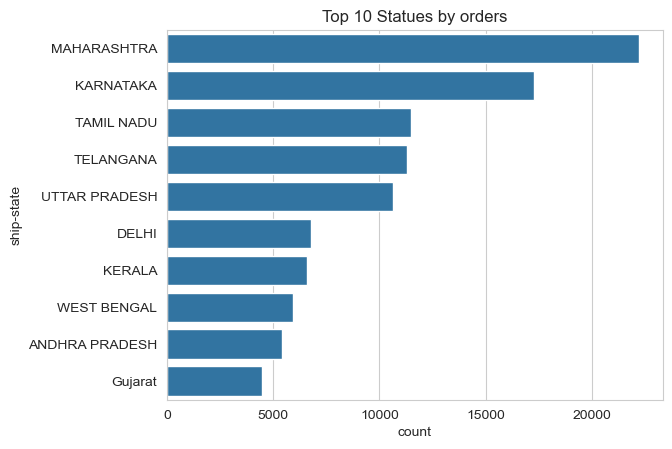

In [16]:
sns.countplot(y="ship-state",data=df,order=df["ship-state"].value_counts().index[:10])
plt.title("Top 10 Statues by orders")
plt.show()

## Time-based Analysis

In [20]:
df['Date']=pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.month
monthly_sales=df.groupby("Month")["Amount"].sum()
monthly_sales


Month
3      101683.85
4    28742816.41
5    26226476.75
6    23425809.38
Name: Amount, dtype: float64

<Axes: xlabel='Month'>

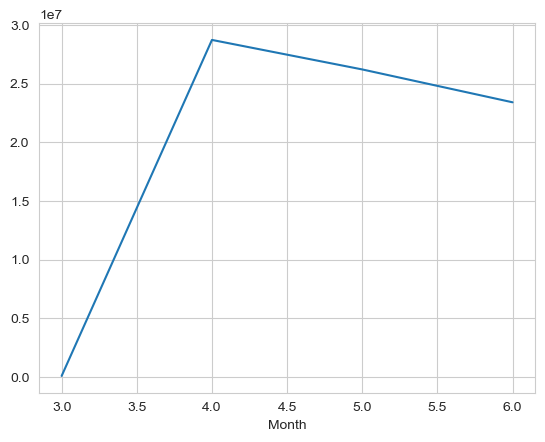

In [23]:
df.groupby("Month")["Amount"].sum().plot(kind="line")


## Advanced state Analysis

In [28]:
top_customer=df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False).head(5)
top_customer

ship-state
MAHARASHTRA      13318966.38
KARNATAKA        10465387.03
TELANGANA         6909670.08
UTTAR PRADESH     6814126.08
TAMIL NADU        6510503.73
Name: Amount, dtype: float64

## Business Insights
1] Clothing category generated the highest revenue.
2] Most orders come from Maharashtra and jarnataka.
3] Some categories sell more quantity but generate lower revenue.
4] Sales peak in month x indicates seasonal demand
5] Top state contribute majority revenue,